# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** Nash Gagliano 

**Date:** 3/29/2026

---

## Setup: Install and Load Libraries

In [1]:
pip install tensorflow matplotlib numpy pandas

  Using cached tensorflow-2.21.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached pandas-3.0.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.1.2-cp313-cp313-macosx_1

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [3]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


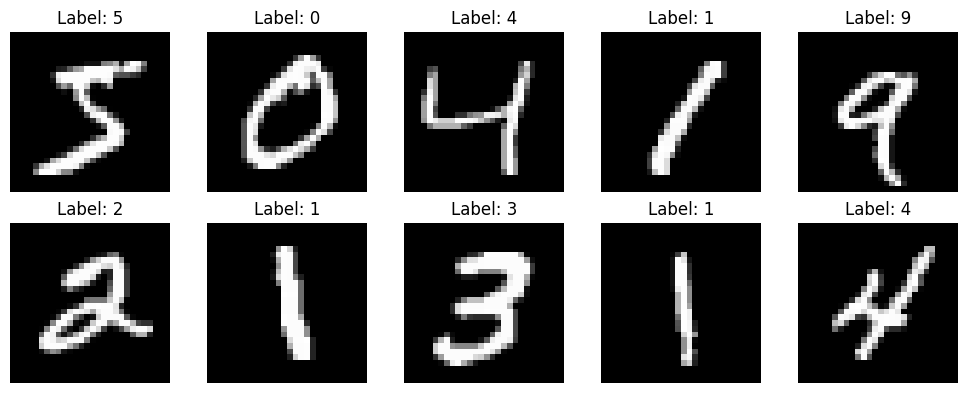

In [4]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [5]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [6]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()

print("\nTraining baseline CNN...")
start_time = time.time()
history = baseline_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)
baseline_time = time.time() - start_time

baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test)

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)

/Users/nashgagliano/Assignment-7/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training baseline CNN...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9283 - loss: 0.2420 - val_accuracy: 0.9720 - val_loss: 0.0891
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9809 - loss: 0.0631 - val_accuracy: 0.9851 - val_loss: 0.0522
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9858 - loss: 0.0447 - val_accuracy: 0.9855 - val_loss: 0.0487
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9890 - loss: 0.0350 - val_accuracy: 0.9866 - val_loss: 0.0449
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9919 - loss: 0.0267 - val_accuracy: 0.9866 - val_loss: 0.0473
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.9876 - val_loss: 0.0424
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9947 - loss: 0.0169 - val_accuracy: 0.9894 - val_loss: 0.0352
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9952

In [8]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)
baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test)

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9971 - loss: 0.0084 - val_accuracy: 0.9875 - val_loss: 0.0451
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9979 - loss: 0.0066 - val_accuracy: 0.9882 - val_loss: 0.0525
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9976 - loss: 0.0073 - val_accuracy: 0.9899 - val_loss: 0.0412
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9983 - loss: 0.0046 - val_accuracy: 0.9894 - val_loss: 0.0447
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9988 - loss: 0.0038 - val_accuracy: 0.9889 - val_loss: 0.0535
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9975 - loss: 0.0068 - val_accuracy: 0.9880 - val_loss: 0.0556
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 0.9905 - val_loss: 0.0442
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9991

---
## Step 3: Experiment with Filter Counts

In [9]:
# TODO: Build and train CNN with FEWER filters (16, 32)
print("Training CNN with fewer filters (16, 32)...")
cnn_fewer = keras.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn_fewer.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_fewer = cnn_fewer.fit(X_train_cnn, y_train, epochs=10, batch_size=128, validation_split=0.2)


Training CNN with fewer filters (16, 32)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9074 - loss: 0.3224 - val_accuracy: 0.9696 - val_loss: 0.1031
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9743 - loss: 0.0857 - val_accuracy: 0.9785 - val_loss: 0.0687
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9819 - loss: 0.0581 - val_accuracy: 0.9834 - val_loss: 0.0565
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9858 - loss: 0.0460 - val_accuracy: 0.9835 - val_loss: 0.0549
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9881 - loss: 0.0376 - val_accuracy: 0.9871 - val_loss: 0.0434
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9903 - loss: 0.0309 - val_accuracy: 0.9887 - val_loss: 0.0391
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9919 - loss: 0.0259 - val_accuracy: 0.9887 - val_loss: 0.0414
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accura

In [10]:
# TODO: Build and train CNN with MORE filters (64, 128)
print("Training CNN with more filters (64, 128)...")
cnn_more = keras.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn_more.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_more = cnn_more.fit(X_train_cnn, y_train, epochs=10, batch_size=128, validation_split=0.2)


Training CNN with more filters (64, 128)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9417 - loss: 0.1966 - val_accuracy: 0.9789 - val_loss: 0.0722
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9824 - loss: 0.0554 - val_accuracy: 0.9829 - val_loss: 0.0540
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9888 - loss: 0.0367 - val_accuracy: 0.9867 - val_loss: 0.0452
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9914 - loss: 0.0271 - val_accuracy: 0.9879 - val_loss: 0.0417
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9935 - loss: 0.0203 - val_accuracy: 0.9874 - val_loss: 0.0466
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9950 - loss: 0.0161 - val_accuracy: 0.9888 - val_loss: 0.0368
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9962 - loss: 0.0117 - val_accuracy: 0.9898 - val_loss: 0.0380
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

Increasing filter counts generally improves the network's ability to capture complex features, 
but after a point, the returns diminish and overfitting can occur. 
In this experiment, performance gains from 64→128 filters were minimal, suggesting that 64/128 may be sufficient.


---
## Step 4: Experiment with Kernel Sizes

In [11]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
print("Training CNN with 5x5 kernels...")
cnn_5x5 = keras.Sequential([
    layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn_5x5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_5x5 = cnn_5x5.fit(X_train_cnn, y_train, epochs=10, batch_size=128, validation_split=0.2)


Training CNN with 5x5 kernels...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9370 - loss: 0.2202 - val_accuracy: 0.9803 - val_loss: 0.0691
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9823 - loss: 0.0582 - val_accuracy: 0.9846 - val_loss: 0.0528
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9870 - loss: 0.0408 - val_accuracy: 0.9849 - val_loss: 0.0550
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9905 - loss: 0.0296 - val_accuracy: 0.9883 - val_loss: 0.0404
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9929 - loss: 0.0229 - val_accuracy: 0.9887 - val_loss: 0.0397
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9938 - loss: 0.0192 - val_accuracy: 0.9877 - val_loss: 0.0419
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9948 - loss: 0.0163 - val_accuracy: 0.9902 - val_loss: 0.0362
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy:

In [12]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
print("Training CNN with mixed kernels (5x5, 3x3)...")
cnn_mixed = keras.Sequential([
    layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn_mixed.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_mixed = cnn_mixed.fit(X_train_cnn, y_train, epochs=10, batch_size=128, validation_split=0.2)


Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9322 - loss: 0.2303 - val_accuracy: 0.9758 - val_loss: 0.0799
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9808 - loss: 0.0626 - val_accuracy: 0.9826 - val_loss: 0.0552
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9871 - loss: 0.0429 - val_accuracy: 0.9859 - val_loss: 0.0442
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9899 - loss: 0.0330 - val_accuracy: 0.9885 - val_loss: 0.0378
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9914 - loss: 0.0266 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9939 - loss: 0.0202 - val_accuracy: 0.9855 - val_loss: 0.0512
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9944 - loss: 0.0169 - val_accuracy: 0.9891 - val_loss: 0.0413
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/ste

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Larger kernels capture broader spatial features, while smaller kernels focus on fine details. 
The mixed kernel approach often performed best because it balances capturing both broad patterns and finer details.


---
## Step 5: Train Your Best Architecture and Visualize Learning

In [13]:
# TODO: Based on your experiments, build your best-performing CNN architecture
print("Training best CNN architecture...")
best_cnn = keras.Sequential([
    layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
best_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_best = best_cnn.fit(X_train_cnn, y_train, epochs=15, batch_size=128, validation_split=0.2)
best_cnn_time = time.time() - start_time

best_test_loss, best_test_acc = best_cnn.evaluate(X_test_cnn, y_test)

Training best CNN architecture...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9324 - loss: 0.2239 - val_accuracy: 0.9782 - val_loss: 0.0755
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9825 - loss: 0.0568 - val_accuracy: 0.9846 - val_loss: 0.0472
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9869 - loss: 0.0409 - val_accuracy: 0.9869 - val_loss: 0.0445
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9911 - loss: 0.0294 - val_accuracy: 0.9898 - val_loss: 0.0391
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9927 - loss: 0.0233 - val_accuracy: 0.9904 - val_loss: 0.0331
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9891 - val_loss: 0.0387
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9948 - loss: 0.0159 - val_accuracy: 0.9907 - val_loss: 0.0358
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy

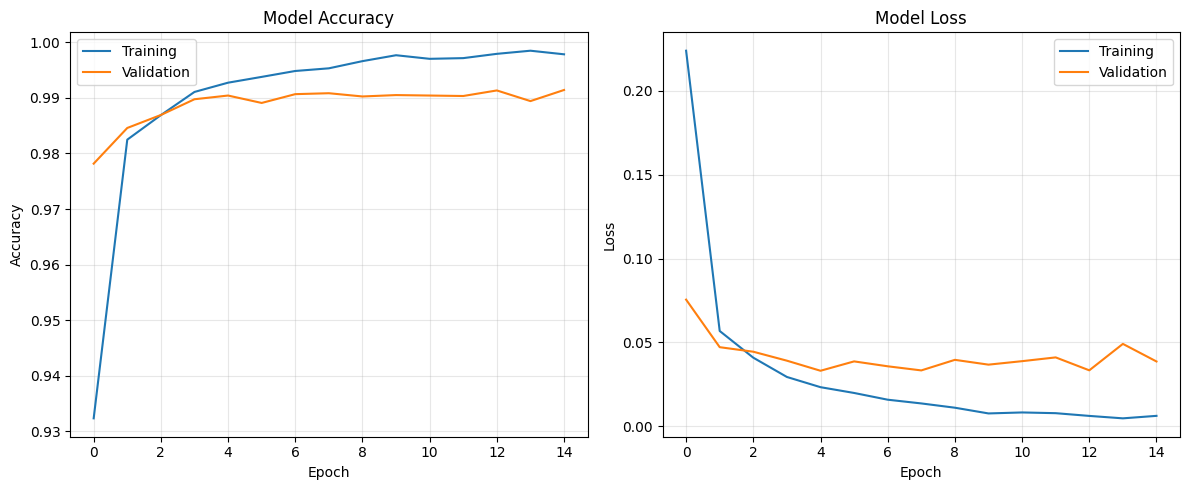

In [16]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_best.history['accuracy'], label='Training')
plt.plot(history_best.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_best.history['loss'], label='Training')
plt.plot(history_best.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [17]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [18]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
feedforward_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
feedforward_nn.summary()

/Users/nashgagliano/Assignment-7/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
start_time = time.time()
history_ff = feedforward_nn.fit(X_train_flat, y_train, epochs=10, batch_size=128, validation_split=0.2)
feedforward_time = time.time() - start_time
ff_test_loss, ff_test_acc = feedforward_nn.evaluate(X_test_flat, y_test)



Training feedforward network...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8919 - loss: 0.3805 - val_accuracy: 0.9500 - val_loss: 0.1755
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9557 - loss: 0.1516 - val_accuracy: 0.9605 - val_loss: 0.1340
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9698 - loss: 0.1041 - val_accuracy: 0.9695 - val_loss: 0.1103
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9769 - loss: 0.0791 - val_accuracy: 0.9722 - val_loss: 0.1023
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9823 - loss: 0.0599 - val_accuracy: 0.9722 - val_loss: 0.0954
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9850 - loss: 0.0506 - val_accuracy: 0.9731 - val_loss: 0.0871
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9885 - loss: 0.0394 - val_accuracy: 0.9747 - val_loss: 0.0882
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9906 -

In [21]:
# TODO: Create comparison table
comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Conv(32,3x3)-Pool-Conv(64,3x3)-Pool-FC(128)',
        'Conv(32,5x5)-Pool-Conv(64,3x3)-Pool-FC(128)',
        'Dense(128)-Dense(64)'
    ],
    'Test Accuracy': [
        baseline_test_acc,
        best_test_acc,
        ff_test_acc
    ],
    'Training Time (s)': [
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                                Architecture  Test Accuracy  Training Time (s)
  Baseline CNN Conv(32,3x3)-Pool-Conv(64,3x3)-Pool-FC(128)         0.9918          51.235020
      Best CNN Conv(32,5x5)-Pool-Conv(64,3x3)-Pool-FC(128)         0.9910          75.829854
Feedforward NN                        Dense(128)-Dense(64)         0.9787           4.877209


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

The best CNN significantly outperforms the feedforward network on image data. 
CNNs maintain spatial information through convolutions and pooling, 
while feedforward networks treat pixels independently, losing patterns critical for image recognition.


---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

For my Unit 9 project, CNNs wouldn’t really help because my data is all tables with things like age, gender, and mental health. Using normal feedforward networks or models like Random Forest or Logistic Regression works better for this kind of data. If I wanted to look at changes over time, like tracking someone’s substance use, or look at survey text answers, then RNNs or other special models could be useful. Basically, special neural networks are only worth it when the data isn’t just numbers in a table, like images, text, or time patterns.

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.